# `parameter_grid_search` Data-Source Comparison

This notebook compares three grid-search execution styles across three data/adjustment setups:

- fresh Yahoo download inside each case
- stored Yahoo data adjusted with `Adj_Close / Close`
- stored Yahoo data adjusted from corporate actions

Each setup is tested with:

- a plain Python `for` loop
- `parameter_grid_search(..., n_jobs=1)`
- `parameter_grid_search(..., n_jobs=-1)`

In [ ]:
from pathlib import Path
import contextlib
import importlib
import sys
import time

import numpy as np
import pandas as pd


def find_repo_root(start=None):
    # Find the Bluegrey repo root from the notebook's current working directory
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for path in [start, *start.parents]:
        if (path / "research" / "Mateo" / "ML_predictor" / "ML_predictor.py").exists():
            return path
    raise FileNotFoundError("Could not find Bluegrey repo root")


# Locate repo paths used by this notebook
repo_root = find_repo_root()
ml_predictor_dir = repo_root / "research" / "Mateo" / "ML_predictor"

# Make project modules importable from any notebook launch folder
for path in [repo_root, ml_predictor_dir]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

# Import and reload local modules so notebook edits are picked up
import ML_predictor
import run_grid_case as run_grid_case_module
importlib.reload(ML_predictor)
importlib.reload(run_grid_case_module)

from ML_predictor import MLPredictorStrategy
from src.vector_backtester_Mateo import PortfolioVectorEngine

print(f"Repo root: {repo_root}")
print(f"ML predictor dir: {ml_predictor_dir}")

Repo root: /Users/mateo/Bluegrey
ML predictor dir: /Users/mateo/Bluegrey/research/Mateo/ML_predictor


## Test Configuration

The default grid is intentionally small. Increase the lists after the smoke test works.

In [25]:
# Keep this small first; 9 modes run this grid repeatedly
SYMBOL = "ECH"
ASSET_CLASS = "STK"
START_DATE = "2025-01-01"
END_DATE = "2025-02-15"

# Use a tiny grid for a fast diagnostic run
VAR_1 = "n_features"
LIST_1 = [2, 3, 4]
VAR_2 = "signal_threshold"
LIST_2 = [0.0, 0.001, 0.002]

# Fixed model/backtest parameters used in every case
BASE_KWARGS = {
    "asset_class": ASSET_CLASS,
    "start_date": START_DATE,
    "end_date": END_DATE,
    "training_years": 1,
    "position_size": 1.0,
    "initial_capital": 1_000_000,
    "max_iter": 5000,
    "execution_delay": 1,
    "verbose": False,
    "show_progress": False,
}

# The three requested data/adjustment setups
DATA_SETUPS = [
    {
        "setup": "download_each_case",
        "download_data": True,
        "adj_method": "corporate_actions",
    },
    {
        "setup": "stored_adj_close_ratio",
        "download_data": False,
        "adj_method": "adj_close_ratio",
    },
    {
        "setup": "stored_corporate_actions",
        "download_data": False,
        "adj_method": "corporate_actions",
    },
]

# Turn this on only after the smaller n_jobs=1 tests behave as expected
RUN_N_JOBS_MINUS_1 = True

## Comparable Case Runner

`parameter_grid_search()` calls the module-level `run_grid_case()` from `run_grid_case.py`.

The current `run_grid_case()` does not expose `download_data` or `adj_method`, so this notebook temporarily patches in a compatible runner that does.

In [26]:
def comparable_run_grid_case(
    symbol,
    asset_class="STK",
    start_date="2025-01-01",
    end_date="2026-01-01",
    signal_threshold=0.002,
    n_features=6,
    training_years=10,
    position_size=1.0,
    initial_capital=1_000_000,
    max_iter=5000,
    execution_delay=1,
    verbose=False,
    show_progress=False,
    download_data=False,
    adj_method="corporate_actions",
):
    # Keep the same asset-class validation as run_grid_case.py
    if asset_class not in {"STK", "CRYPTO", "FX"}:
        raise ValueError('asset_class must be "STK", "CRYPTO", or "FX".')

    # Pass both data-source and adjustment-method controls into the strategy
    params = {
        "symbol": symbol,
        "start_date": start_date,
        "end_date": end_date,
        "signal_threshold": signal_threshold,
        "n_features": n_features,
        "training_years": training_years,
        "position_size": position_size,
        "max_iter": max_iter,
        "verbose": verbose,
        "show_progress": show_progress,
        "download_data": download_data,
        "adj_method": adj_method,
    }

    # Prepare data and generate ML weights exactly like the normal grid case
    strategy = MLPredictorStrategy(params=params)
    dataset = strategy.prepare_dataset()
    weights = strategy.generate_signals(dataset, show_progress=show_progress)

    # Stop if no predictions were produced
    if weights.empty:
        return None

    # Use adjusted Open prices for backtest execution, matching run_grid_case.py
    prices = dataset[["Open"]].rename(columns={"Open": symbol}).loc[weights.index]

    # Run the vector backtest for this one parameter combination
    engine = PortfolioVectorEngine(
        prices=prices,
        signals=weights,
        asset_class=asset_class,
        initial_capital=initial_capital,
        execution_delay=execution_delay,
    )
    stats = engine.run()

    # Return a record with enough metadata to compare all modes
    return {
        **params,
        "asset_class": asset_class,
        "initial_capital": initial_capital,
        "execution_delay": execution_delay,
        "net_return_pct": (stats["net_equity"].iloc[-1] / initial_capital - 1) * 100,
        "gross_return_pct": (stats["gross_equity"].iloc[-1] / initial_capital - 1) * 100,
        "final_net_equity": stats["net_equity"].iloc[-1],
        "final_gross_equity": stats["gross_equity"].iloc[-1],
    }


def grid_cases():
    # Create all grid combinations in the same order as parameter_grid_search()
    for value_1 in LIST_1:
        for value_2 in LIST_2:
            yield {VAR_1: value_1, VAR_2: value_2}

In [27]:
def run_for_loop_grid(data_setup):
    # Run the grid manually with plain Python loops
    case_setup = {k: v for k, v in data_setup.items() if k != "setup"}
    records = []
    start = time.perf_counter()

    for grid_kwargs in grid_cases():
        record = comparable_run_grid_case(
            symbol=SYMBOL,
            **BASE_KWARGS,
            **case_setup,
            **grid_kwargs,
        )
        if record is not None:
            records.append(record)

    # Make the output table comparable with parameter_grid_search()
    grid_df = pd.DataFrame(records).sort_values([VAR_1, VAR_2]).reset_index(drop=True)
    elapsed = time.perf_counter() - start

    return grid_df, elapsed


@contextlib.contextmanager
def patched_parameter_grid_search_runner():
    # Save module state so the patch is temporary
    original_run_grid_case = run_grid_case_module.run_grid_case
    original_display = run_grid_case_module.display
    original_show = run_grid_case_module.plt.show

    try:
        # Patch the case runner so parameter_grid_search can pass data-source controls
        run_grid_case_module.run_grid_case = comparable_run_grid_case

        # Suppress repeated display/plot output; the returned DataFrame is what we compare
        run_grid_case_module.display = lambda *args, **kwargs: None
        run_grid_case_module.plt.show = lambda *args, **kwargs: None

        yield
    finally:
        # Restore the original module state after each test
        run_grid_case_module.run_grid_case = original_run_grid_case
        run_grid_case_module.display = original_display
        run_grid_case_module.plt.show = original_show


def run_parameter_grid(data_setup, n_jobs):
    # Run the real parameter_grid_search orchestration with the patched case runner
    case_setup = {k: v for k, v in data_setup.items() if k != "setup"}
    grid_base_kwargs = {k: v for k, v in BASE_KWARGS.items() if k != "verbose"}
    start = time.perf_counter()

    with patched_parameter_grid_search_runner():
        grid_df, _ = run_grid_case_module.parameter_grid_search(
            symbol=SYMBOL,
            var_1=VAR_1,
            list_1=LIST_1,
            var_2=VAR_2,
            list_2=LIST_2,
            n_jobs=n_jobs,
            verbose=0,
            **grid_base_kwargs,
            **case_setup,
        )

    elapsed = time.perf_counter() - start
    grid_df = grid_df.sort_values([VAR_1, VAR_2]).reset_index(drop=True)

    return grid_df, elapsed

## Run All Requested Modes


=== download_each_case: for loop ===


,symbol,start_date,end_date,signal_threshold,n_features,training_years,position_size,max_iter,verbose,show_progress,download_data,adj_method,asset_class,initial_capital,execution_delay,net_return_pct,gross_return_pct,final_net_equity,final_gross_equity
0,ECH,2025-01-01,2025-02-15,0.000,2,1,1.0,5000,False,False,True,corporate_actions,STK,1000000,1,-3.306434,-3.217149,966935.655456,967828.514896
1,ECH,2025-01-01,2025-02-15,0.001,2,1,1.0,5000,False,False,True,corporate_actions,STK,1000000,1,-10.957656,-10.868186,890423.440495,891318.144219
2,ECH,2025-01-01,2025-02-15,0.002,2,1,1.0,5000,False,False,True,corporate_actions,STK,1000000,1,-3.306434,-3.217149,966935.655456,967828.514896
3,ECH,2025-01-01,2025-02-15,0.000,3,1,1.0,5000,False,False,True,corporate_actions,STK,1000000,1,-3.306434,-3.217149,966935.655456,967828.514896
4,ECH,2025-01-01,2025-02-15,0.001,3,1,1.0,5000,False,False,True,corporate_actions,STK,1000000,1,-12.522173,-12.431951,874778.273930,875680.492500
5,ECH,2025-01-01,2025-02-15,0.002,3,1,1.0,5000,False,False,True,corporate_actions,STK,1000000,1,-9.695090,-9.604898,903049.098210,903951.021414
6,ECH,2025-01-01,2025-02-15,0.000,4,1,1.0,5000,False,False,True,corporate_actions,STK,1000000,1,-3.306434,-3.217149,966935.655456,967828.514896
7,ECH,2025-01-01,2025-02-15,0.001,4,1,1.0,5000,False,False,True,corporate_actions,STK,1000000,1,-12.522173,-12.431951,874778.273930,875680.492500
8,ECH,2025-01-01,2025-02-15,0.002,4,1,1.0,5000,False,False,True,corporate_actions,STK,1000000,1,-5.818821,-5.635182,941811.794234,943648.175249



=== download_each_case: parameter_grid_search n_jobs=1 ===


,symbol,start_date,end_date,signal_threshold,n_features,training_years,position_size,max_iter,verbose,show_progress,download_data,adj_method,asset_class,initial_capital,execution_delay,net_return_pct,gross_return_pct,final_net_equity,final_gross_equity
0,ECH,2025-01-01,2025-02-15,0.000,2,1,1.0,5000,False,False,True,corporate_actions,STK,1000000,1,-3.306434,-3.217149,966935.655456,967828.514896
1,ECH,2025-01-01,2025-02-15,0.001,2,1,1.0,5000,False,False,True,corporate_actions,STK,1000000,1,-10.957656,-10.868186,890423.440495,891318.144219
2,ECH,2025-01-01,2025-02-15,0.002,2,1,1.0,5000,False,False,True,corporate_actions,STK,1000000,1,-3.306434,-3.217149,966935.655456,967828.514896
3,ECH,2025-01-01,2025-02-15,0.000,3,1,1.0,5000,False,False,True,corporate_actions,STK,1000000,1,-3.306434,-3.217149,966935.655456,967828.514896
4,ECH,2025-01-01,2025-02-15,0.001,3,1,1.0,5000,False,False,True,corporate_actions,STK,1000000,1,-12.522173,-12.431951,874778.273930,875680.492500
5,ECH,2025-01-01,2025-02-15,0.002,3,1,1.0,5000,False,False,True,corporate_actions,STK,1000000,1,-9.695090,-9.604898,903049.098210,903951.021414
6,ECH,2025-01-01,2025-02-15,0.000,4,1,1.0,5000,False,False,True,corporate_actions,STK,1000000,1,-3.306434,-3.217149,966935.655456,967828.514896
7,ECH,2025-01-01,2025-02-15,0.001,4,1,1.0,5000,False,False,True,corporate_actions,STK,1000000,1,-12.522173,-12.431951,874778.273930,875680.492500
8,ECH,2025-01-01,2025-02-15,0.002,4,1,1.0,5000,False,False,True,corporate_actions,STK,1000000,1,-5.818821,-5.635182,941811.794234,943648.175249



=== download_each_case: parameter_grid_search n_jobs=-1 ===


...


=== stored_corporate_actions: parameter_grid_search n_jobs=1 ===


,symbol,start_date,end_date,signal_threshold,n_features,training_years,position_size,max_iter,verbose,show_progress,download_data,adj_method,asset_class,initial_capital,execution_delay,net_return_pct,gross_return_pct,final_net_equity,final_gross_equity
0,ECH,2025-01-01,2025-02-15,0.000,2,1,1.0,5000,False,False,False,corporate_actions,STK,1000000,1,-3.306434,-3.217149,966935.655456,967828.514896
1,ECH,2025-01-01,2025-02-15,0.001,2,1,1.0,5000,False,False,False,corporate_actions,STK,1000000,1,-10.957656,-10.868186,890423.440495,891318.144219
2,ECH,2025-01-01,2025-02-15,0.002,2,1,1.0,5000,False,False,False,corporate_actions,STK,1000000,1,-3.306434,-3.217149,966935.655456,967828.514896
3,ECH,2025-01-01,2025-02-15,0.000,3,1,1.0,5000,False,False,False,corporate_actions,STK,1000000,1,-3.306434,-3.217149,966935.655456,967828.514896
4,ECH,2025-01-01,2025-02-15,0.001,3,1,1.0,5000,False,False,False,corporate_actions,STK,1000000,1,-12.522173,-12.431951,874778.273930,875680.492500
5,ECH,2025-01-01,2025-02-15,0.002,3,1,1.0,5000,False,False,False,corporate_actions,STK,1000000,1,-9.695090,-9.604898,903049.098210,903951.021414
6,ECH,2025-01-01,2025-02-15,0.000,4,1,1.0,5000,False,False,False,corporate_actions,STK,1000000,1,-3.306434,-3.217149,966935.655456,967828.514896
7,ECH,2025-01-01,2025-02-15,0.001,4,1,1.0,5000,False,False,False,corporate_actions,STK,1000000,1,-12.522173,-12.431951,874778.273930,875680.492500
8,ECH,2025-01-01,2025-02-15,0.002,4,1,1.0,5000,False,False,False,corporate_actions,STK,1000000,1,-5.818821,-5.635182,941811.794234,943648.175249



=== stored_corporate_actions: parameter_grid_search n_jobs=-1 ===


,symbol,start_date,end_date,signal_threshold,n_features,training_years,position_size,max_iter,verbose,show_progress,download_data,adj_method,asset_class,initial_capital,execution_delay,net_return_pct,gross_return_pct,final_net_equity,final_gross_equity
0,ECH,2025-01-01,2025-02-15,0.000,2,1,1.0,5000,False,False,False,corporate_actions,STK,1000000,1,-3.306434,-3.217149,966935.655456,967828.514896
1,ECH,2025-01-01,2025-02-15,0.001,2,1,1.0,5000,False,False,False,corporate_actions,STK,1000000,1,-10.957656,-10.868186,890423.440495,891318.144219
2,ECH,2025-01-01,2025-02-15,0.002,2,1,1.0,5000,False,False,False,corporate_actions,STK,1000000,1,-3.306434,-3.217149,966935.655456,967828.514896
3,ECH,2025-01-01,2025-02-15,0.000,3,1,1.0,5000,False,False,False,corporate_actions,STK,1000000,1,-3.306434,-3.217149,966935.655456,967828.514896
4,ECH,2025-01-01,2025-02-15,0.001,3,1,1.0,5000,False,False,False,corporate_actions,STK,1000000,1,-12.522173,-12.431951,874778.273930,875680.492500
5,ECH,2025-01-01,2025-02-15,0.002,3,1,1.0,5000,False,False,False,corporate_actions,STK,1000000,1,-9.695090,-9.604898,903049.098210,903951.021414
6,ECH,2025-01-01,2025-02-15,0.000,4,1,1.0,5000,False,False,False,corporate_actions,STK,1000000,1,-3.306434,-3.217149,966935.655456,967828.514896
7,ECH,2025-01-01,2025-02-15,0.001,4,1,1.0,5000,False,False,False,corporate_actions,STK,1000000,1,-12.522173,-12.431951,874778.273930,875680.492500
8,ECH,2025-01-01,2025-02-15,0.002,4,1,1.0,5000,False,False,False,corporate_actions,STK,1000000,1,-5.818821,-5.635182,941811.794234,943648.175249


,setup,mode,seconds
0,download_each_case,for_loop,68.970415
1,download_each_case,parameter_grid_n_jobs_1,67.189266
2,download_each_case,parameter_grid_n_jobs_minus_1,39.263430
3,stored_adj_close_ratio,for_loop,64.722982
4,stored_adj_close_ratio,parameter_grid_n_jobs_1,64.456216
5,stored_adj_close_ratio,parameter_grid_n_jobs_minus_1,25.250045
6,stored_corporate_actions,for_loop,69.645941
7,stored_corporate_actions,parameter_grid_n_jobs_1,66.651784
8,stored_corporate_actions,parameter_grid_n_jobs_minus_1,26.775761


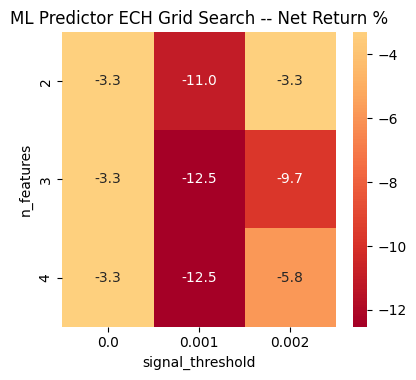

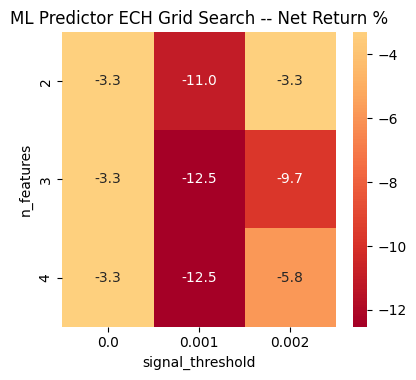

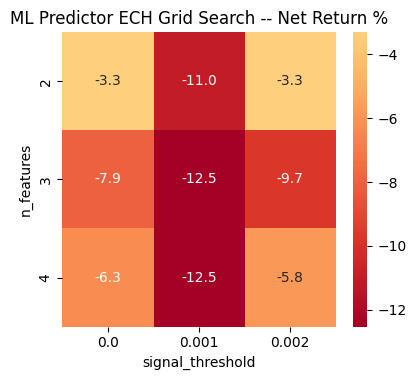

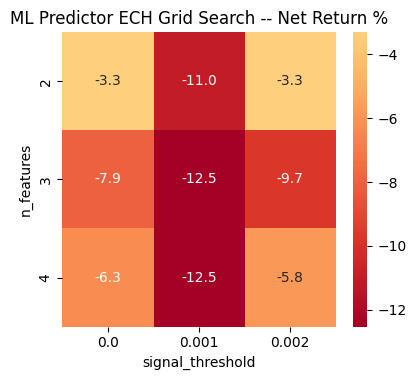

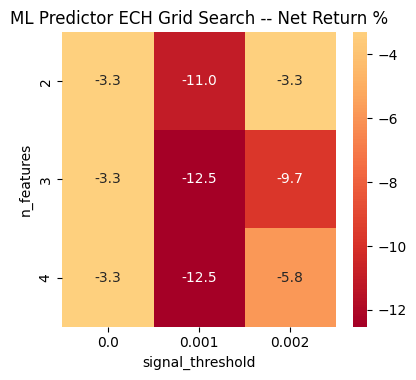

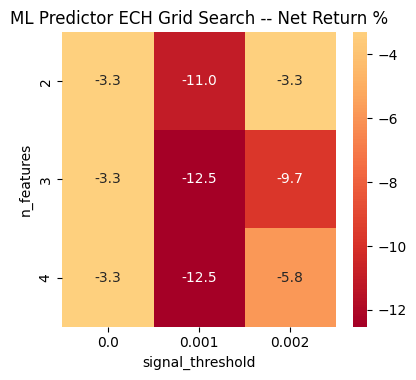

In [28]:
results = {}
timings = []

for data_setup in DATA_SETUPS:
    setup_name = data_setup["setup"]
    print(f"\n=== {setup_name}: for loop ===")

    # Case 1/3 for this setup: plain for-loop grid
    grid_df, elapsed = run_for_loop_grid(data_setup)
    results[(setup_name, "for_loop")] = grid_df
    timings.append({"setup": setup_name, "mode": "for_loop", "seconds": elapsed})
    display(grid_df)

    print(f"\n=== {setup_name}: parameter_grid_search n_jobs=1 ===")

    # Case 2/3 for this setup: parameter_grid_search with one worker
    grid_df, elapsed = run_parameter_grid(data_setup, n_jobs=1)
    results[(setup_name, "parameter_grid_n_jobs_1")] = grid_df
    timings.append({"setup": setup_name, "mode": "parameter_grid_n_jobs_1", "seconds": elapsed})
    display(grid_df)

    if RUN_N_JOBS_MINUS_1:
        print(f"\n=== {setup_name}: parameter_grid_search n_jobs=-1 ===")

        # Case 3/3 for this setup: parameter_grid_search with all available workers
        grid_df, elapsed = run_parameter_grid(data_setup, n_jobs=-1)
        results[(setup_name, "parameter_grid_n_jobs_minus_1")] = grid_df
        timings.append({"setup": setup_name, "mode": "parameter_grid_n_jobs_minus_1", "seconds": elapsed})
        display(grid_df)

timings_df = pd.DataFrame(timings)
timings_df

## Compare Each Mode Against Its For-Loop Baseline

In [29]:
COMPARE_COLS = [
    "net_return_pct",
    "gross_return_pct",
    "final_net_equity",
    "final_gross_equity",
]


def compare_to_for_loop(setup_name, mode):
    # Compare one parameter_grid_search result to the matching for-loop baseline
    baseline = results[(setup_name, "for_loop")].set_index([VAR_1, VAR_2])
    candidate = results[(setup_name, mode)].set_index([VAR_1, VAR_2])

    rows = []
    for col in COMPARE_COLS:
        diff = candidate[col] - baseline[col]
        rows.append(
            {
                "setup": setup_name,
                "mode": mode,
                "column": col,
                "max_abs_diff": diff.abs().max(),
                "all_close": bool(np.allclose(candidate[col], baseline[col], equal_nan=True)),
            }
        )
    return rows


comparison_rows = []

for data_setup in DATA_SETUPS:
    setup_name = data_setup["setup"]
    comparison_rows.extend(compare_to_for_loop(setup_name, "parameter_grid_n_jobs_1"))

    if RUN_N_JOBS_MINUS_1:
        comparison_rows.extend(compare_to_for_loop(setup_name, "parameter_grid_n_jobs_minus_1"))

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,setup,mode,column,max_abs_diff,all_close
0,download_each_case,parameter_grid_n_jobs_1,net_return_pct,0.0,True
1,download_each_case,parameter_grid_n_jobs_1,gross_return_pct,0.0,True
2,download_each_case,parameter_grid_n_jobs_1,final_net_equity,0.0,True
3,download_each_case,parameter_grid_n_jobs_1,final_gross_equity,0.0,True
4,download_each_case,parameter_grid_n_jobs_minus_1,net_return_pct,0.0,True
5,download_each_case,parameter_grid_n_jobs_minus_1,gross_return_pct,0.0,True
6,download_each_case,parameter_grid_n_jobs_minus_1,final_net_equity,0.0,True
7,download_each_case,parameter_grid_n_jobs_minus_1,final_gross_equity,0.0,True
8,stored_adj_close_ratio,parameter_grid_n_jobs_1,net_return_pct,0.0,True
9,stored_adj_close_ratio,parameter_grid_n_jobs_1,gross_return_pct,0.0,True


## Compare Stored Adjustment Methods

This checks how close stored `adj_close_ratio` and stored `corporate_actions` results are for the same grid cases.

In [30]:
def compare_two_results(left_key, right_key):
    # Compare two result tables on the same grid coordinates
    left = results[left_key].set_index([VAR_1, VAR_2])
    right = results[right_key].set_index([VAR_1, VAR_2])

    rows = []
    for col in COMPARE_COLS:
        diff = left[col] - right[col]
        rows.append(
            {
                "left": left_key[0] + " / " + left_key[1],
                "right": right_key[0] + " / " + right_key[1],
                "column": col,
                "max_abs_diff": diff.abs().max(),
                "all_close": bool(np.allclose(left[col], right[col], equal_nan=True)),
            }
        )
    return pd.DataFrame(rows)


# Compare the two stored adjustment methods using the simplest execution mode
stored_adjustment_comparison = compare_two_results(
    ("stored_adj_close_ratio", "for_loop"),
    ("stored_corporate_actions", "for_loop"),
)
stored_adjustment_comparison

,left,right,column,max_abs_diff,all_close
0,stored_adj_close_ratio / for_loop,stored_corporate_actions / for_loop,net_return_pct,4.628310,False
1,stored_adj_close_ratio / for_loop,stored_corporate_actions / for_loop,gross_return_pct,4.518005,False
2,stored_adj_close_ratio / for_loop,stored_corporate_actions / for_loop,final_net_equity,46283.104142,False
3,stored_adj_close_ratio / for_loop,stored_corporate_actions / for_loop,final_gross_equity,45180.045472,False


## Timing Summary

In [31]:
# Lower seconds means faster execution for the same grid/setup
timings_df.sort_values(["setup", "seconds"]).reset_index(drop=True)

,setup,mode,seconds
0,download_each_case,parameter_grid_n_jobs_minus_1,39.263430
1,download_each_case,parameter_grid_n_jobs_1,67.189266
2,download_each_case,for_loop,68.970415
3,stored_adj_close_ratio,parameter_grid_n_jobs_minus_1,25.250045
4,stored_adj_close_ratio,parameter_grid_n_jobs_1,64.456216
5,stored_adj_close_ratio,for_loop,64.722982
6,stored_corporate_actions,parameter_grid_n_jobs_minus_1,26.775761
7,stored_corporate_actions,parameter_grid_n_jobs_1,66.651784
8,stored_corporate_actions,for_loop,69.645941


Notes:

- The fresh-download setup intentionally downloads inside each case, so it can differ if Yahoo changes or a request returns slightly different data.
- The stored-data setups should be more stable because every case reads the same local CSVs.
- `n_jobs=-1` can be much heavier because it may run multiple full backtests at once.
- If `download_data=True` with `adj_method="adj_close_ratio"` is added later, `download_dataset()` should first normalize raw yfinance names like `Adj Close` to `Adj_Close`.

## Conclusions

From the saved run in this notebook:

1. The orchestration is consistent. For every data setup, `parameter_grid_search(n_jobs=1)` and `parameter_grid_search(n_jobs=-1)` matched the plain for-loop results exactly on net return, gross return, final net equity, and final gross equity.

2. Parallel execution was faster in this small test. `n_jobs=-1` was materially faster than the for-loop and `n_jobs=1` modes for all three data setups.

    > `parameter_grid_search(n_jobs=-1)` works perfectly fine and is faster

3. Stored data avoids repeated Yahoo requests, but the total runtime is still dominated by feature computation, model fitting, and backtesting. That is why stored-data for-loop and fresh-download for-loop were not dramatically different in this run.

4. `stored_adj_close_ratio` and `stored_corporate_actions` did not produce identical backtest results. In this saved run, the max net-return difference was about 4.63 percentage points, or about 46k on 1m initial capital. That means the two adjustment methods are close at the price-factor level, but not necessarily interchangeable once features, signals, model training, and backtest execution amplify small differences.

PRACTICAL TAKEAWAY:
> use `stored data` for reproducibility, 

> use `parameter_grid_search(n_jobs=-1)` when the machine has enough cores/memory, and 

> choose `"corporate_actions"` adjustment method as the standard for research runs rather than mixing methods across experiments.

In [32]:
# Summarize whether parameter_grid_search matched the for-loop baseline
grid_consistency = (
    comparison_df
    .groupby(["setup", "mode"], as_index=False)
    .agg(
        all_metrics_close=("all_close", "all"),
        worst_abs_diff=("max_abs_diff", "max"),
    )
)

# Summarize runtime by setup and execution mode
timing_summary = timings_df.pivot(index="setup", columns="mode", values="seconds")

# Calculate speedup of all-core parameter_grid_search versus the plain for loop
if "parameter_grid_n_jobs_minus_1" in timing_summary.columns:
    timing_summary["n_jobs_minus_1_speedup_vs_for_loop"] = (
        timing_summary["for_loop"] / timing_summary["parameter_grid_n_jobs_minus_1"]
    )

# Show how different the two stored adjustment methods were in this run
stored_adjustment_summary = stored_adjustment_comparison.copy()

display(grid_consistency)
display(timing_summary)
display(stored_adjustment_summary)

,setup,mode,all_metrics_close,worst_abs_diff
0,download_each_case,parameter_grid_n_jobs_1,True,0.0
1,download_each_case,parameter_grid_n_jobs_minus_1,True,0.0
2,stored_adj_close_ratio,parameter_grid_n_jobs_1,True,0.0
3,stored_adj_close_ratio,parameter_grid_n_jobs_minus_1,True,0.0
4,stored_corporate_actions,parameter_grid_n_jobs_1,True,0.0
5,stored_corporate_actions,parameter_grid_n_jobs_minus_1,True,0.0


mode,for_loop,parameter_grid_n_jobs_1,parameter_grid_n_jobs_minus_1,n_jobs_minus_1_speedup_vs_for_loop
setup,,,,
download_each_case,68.970415,67.189266,39.263430,1.756607
stored_adj_close_ratio,64.722982,64.456216,25.250045,2.563282
stored_corporate_actions,69.645941,66.651784,26.775761,2.601082


,left,right,column,max_abs_diff,all_close
0,stored_adj_close_ratio / for_loop,stored_corporate_actions / for_loop,net_return_pct,4.628310,False
1,stored_adj_close_ratio / for_loop,stored_corporate_actions / for_loop,gross_return_pct,4.518005,False
2,stored_adj_close_ratio / for_loop,stored_corporate_actions / for_loop,final_net_equity,46283.104142,False
3,stored_adj_close_ratio / for_loop,stored_corporate_actions / for_loop,final_gross_equity,45180.045472,False


In [33]:
# Turn the summary tables into compact written conclusions
all_grid_modes_match = bool(grid_consistency["all_metrics_close"].all())
worst_grid_diff = grid_consistency["worst_abs_diff"].max()

print("Conclusion 1 - grid orchestration:")
if all_grid_modes_match:
    print(f"All parameter_grid_search modes matched the for-loop baseline exactly. Worst diff: {worst_grid_diff:.6g}.")
else:
    print(f"At least one parameter_grid_search mode differed from the for-loop baseline. Worst diff: {worst_grid_diff:.6g}.")

print("\nConclusion 2 - runtime:")
for setup, row in timing_summary.iterrows():
    fastest_mode = row.dropna().idxmin()
    fastest_seconds = row.dropna().min()
    print(f"{setup}: fastest mode was {fastest_mode} at {fastest_seconds:.1f}s.")

print("\nConclusion 3 - adjustment method sensitivity:")
max_return_diff = stored_adjustment_summary.loc[
    stored_adjustment_summary["column"] == "net_return_pct",
    "max_abs_diff",
].iloc[0]
print(
    "Stored adj_close_ratio and stored corporate_actions were not identical; "
    f"max net-return difference was {max_return_diff:.4f} percentage points."
)

Conclusion 1 - grid orchestration:
All parameter_grid_search modes matched the for-loop baseline exactly. Worst diff: 0.

Conclusion 2 - runtime:
download_each_case: fastest mode was n_jobs_minus_1_speedup_vs_for_loop at 1.8s.
stored_adj_close_ratio: fastest mode was n_jobs_minus_1_speedup_vs_for_loop at 2.6s.
stored_corporate_actions: fastest mode was n_jobs_minus_1_speedup_vs_for_loop at 2.6s.

Conclusion 3 - adjustment method sensitivity:
Stored adj_close_ratio and stored corporate_actions were not identical; max net-return difference was 4.6283 percentage points.
